# NB06s — Reptile Meta-Learning ADAPTATIU sobre PPO Agent (Sparse Reward)

**Objectiu**: Entrena un agent PPO amb **Reptile meta-learning adaptatiu** que:
- **Inner loops dinàmics**: Cada tasca s'entrena fins que **convergeix** (mètrica ho detecta)
- **Outer updates automàtics**: Quan s'acumulen N tasques O passa X temps
- **Early stopping global**: Para quan el meta-agent **convergeix** sobre val

## Diferències vs. versió clàssica

| Aspecte | Clàssic | Adaptatiu |
|---------|---------|----------|
| Inner steps | **Fix** (10k steps) | **Dinàmic** (fins convergir, 5k-30k) |
| Batch size | **Fix** (10 tasques) | **Dinàmic** (acumula fins 5 o timeout) |
| Meta iters | **Fix** (15k iters) | **Dinàmic** (para quan val sharpe convergeix) |
| Filtratge | **Cap** | **Automàtic** (només tasques convergides) |
| Budget | **1.5B steps** (!!) | **~10-50M steps** (eficient) |

## Sistema adaptatiu

```
┌─ META-ENTRENAMENT (loop principal) ───────────────────┐
│                                                       │
│  ┌─ INNER LOOP BATCH ──────────────────────────┐    │
│  │  → Tasca 1: entrena fins convergir (Sharpe) │    │
│  │  → Tasca 2: entrena fins convergir          │    │
│  │  → Tasca 3: entrena fins convergir          │    │
│  │  → ... (fins N tasques o timeout)           │    │
│  └──────────────────────────────────────────────┘    │
│              ↓                                        │
│  ┌─ OUTER UPDATE (Reptile) ───────────────────┐     │
│  │  θ ← θ + ε·mean(φᵢ - θ)                    │     │
│  └──────────────────────────────────────────────┘    │
│              ↓                                        │
│  ┌─ AVALUACIÓ META (periòdica) ───────────────┐     │
│  │  Val Sharpe → early stopping?              │     │
│  └──────────────────────────────────────────────┘    │
│              ↓                                        │
│         Convergit? → PARA                             │
│         NO → REPEAT                                   │
└───────────────────────────────────────────────────────┘
```

In [23]:
# =============================================================================
# CEL·LA 1 — IMPORTS
# =============================================================================

import copy
import json
import os as _os
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from codecarbon import EmissionsTracker
from tqdm.auto import tqdm

from src.data.manager import DataManager
from src.rl.agents.actor_critic_policy import ActorCriticPolicy
from src.rl.envs.crypto_market_env_consolidated_reward import (
    CryptoMarketEnvConsolidatedReward, INITIAL_BALANCE, MAX_EPISODE_STEPS,
    steps_per_4h_for,
)
from src.rl.metrics import compute_sharpe, compute_max_drawdown

# Import sistema adaptatiu
# sys.path.insert(0, str(Path.cwd()))
from src.rl.meta_learning import (
    AdaptiveReptile,
    InnerConvergenceCriteria,
    OuterUpdateTrigger,
    MetaConvergenceCriteria,
)

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [24]:
# =============================================================================
# CEL·LA 2 — CONFIGURACIÓ: SEED, DEVICE, PATHS
# =============================================================================

# Reproducibilitat
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# CWD
_cwd = Path.cwd()
if not (_cwd / 'data' / 'processed').exists():
    _root = _cwd.parents[1]
    if (_root / 'data' / 'processed').exists():
        _os.chdir(_root)
        print(f'CWD -> {Path.cwd()}')

# ── SELECTOR: BASE AGENT (MODIFICAR AQUÍ) ────────────────────────────────────
USE_PRETRAINED = False  # True = _adj (ajusta checkpoint), False = _new (fresh init)

# Agents disponibles per meta-learning
AVAILABLE_AGENTS = {
    'ppo_pytorch_dense_final': 'checkpoints_dense/ppo_pytorch_dense_final.pt',
    'ppo_pytorch_sparse_final': 'checkpoints_sparse/ppo_pytorch_sparse_final.pt',
}

BASE_AGENT = 'ppo_pytorch_sparse_final'  # ← CANVIA AIXÒ per seleccionar checkpoint

if BASE_AGENT not in AVAILABLE_AGENTS:
    raise ValueError(f"BASE_AGENT desconegut: '{BASE_AGENT}'")

# ──────────────────────────────────────────────────────────────────────────────

# Paths
BEST_PARAMS_PATH = Path('checkpoints_sparse/ppo_best_params.json')
RESULTS  = Path('results_sparse') / '06s_ppo_reptile_adaptive_new'
RESULTS.mkdir(parents=True, exist_ok=True)
CODECARBON_DIR = RESULTS / 'codecarbon'
CODECARBON_DIR.mkdir(parents=True, exist_ok=True)

# Variant naming: _adj si pre-trained, _new si fresh init
variant = '_adj' if USE_PRETRAINED else '_new'
META_CKPT = Path(f'checkpoints_sparse/ppo_reptile_meta{variant}_adaptative.pt')

# Dades
TIMEFRAME = '60m'
STEPS_PER_WEEK = 7 * 24  # 168 passos/setmana a 60m

print(f'Selector: USE_PRETRAINED={USE_PRETRAINED}, BASE_AGENT={BASE_AGENT}')
print(f'Variant: {variant}')
print(f'Meta checkpoint: {META_CKPT.name}')
print(f'Paths OK')

Device: cuda
Selector: USE_PRETRAINED=False, BASE_AGENT=ppo_pytorch_sparse_final
Variant: _new
Meta checkpoint: ppo_reptile_meta_new_adaptative.pt
Paths OK


In [25]:
# =============================================================================
# CEL·LA 3 — CRITERIS DE CONVERGÈNCIA (sistema adaptatiu)
# =============================================================================

# ── Inner Loop Convergence ───────────────────────────────────────────────────
inner_criteria = InnerConvergenceCriteria(
    min_steps=5_000,                    # Mínim d'steps abans d'avaluar
    max_steps=30_000,                   # Màxim (timeout per tasca)
    eval_every=2_000,                   # Avalua convergència cada 2k steps
    eval_episodes=5,                    # Episodis per avaluar sharpe
    
    # Convergència per performance
    target_sharpe=0.8,                  # Si sharpe >= 0.8 → convergit
    min_sharpe_improvement=0.3,         # Millora mínima des d'inici
    plateau_threshold=0.05,             # Millora <5% → plateau
    plateau_patience=3,                 # 3 evals sense millora → convergit
    
    # Convergència per gradients
    min_grad_norm=0.01,                 # Gradient massa petit → convergit
    max_grad_norm=10.0,                 # Gradient massa gran → divergència
    
    # Convergència per paràmetres
    max_param_distance=15.0,            # ||φ - θ|| massa gran → overfitting
)

# ── Outer Update Trigger ─────────────────────────────────────────────────────
outer_trigger = OuterUpdateTrigger(
    batch_size=5,                       # 5 tasques convergides → outer update
    max_time_seconds=450.0,             # O cada 5 min → outer update
    min_tasks=3,                        # Mínim 3 tasques per update vàlid
)

# ── Meta Convergence (ADAPTATIU segons _new vs _adj) ─────────────────────────
if USE_PRETRAINED:
    # MODE _adj: Model pre-entrenat busca meta-optimalitat
    # → NO target de performance (pot degradar temporalment)
    # → Només plateau detection amb més paciència
    meta_criteria = MetaConvergenceCriteria(
        max_meta_iters=500,
        eval_every=5,
        eval_episodes=25,
        
        target_val_sharpe=None,         # ← NO target absolut (accepta degradació)
        plateau_threshold=0.05,         # ← Més sensible a plateau (5%)
        plateau_patience=30,            # ← Més paciència (30 evals)
        min_val_sharpe=-999.0,          # ← No penalitza degradació
    )
    print('Meta criteria MODE: _adj (sense targets de performance)')
else:
    # MODE _new: Fresh init busca performance alta
    # → Target de performance absolut
    # → Menys paciència, vol arribar a sharpe alt
    meta_criteria = MetaConvergenceCriteria(
        max_meta_iters=500,
        eval_every=5,
        eval_episodes=25,
        
        target_val_sharpe=23.85,         # ← Target absolut (0.75 x Sharpe entrenament estàndard)
        plateau_threshold=0.1,          # ← Menys sensible (10%)
        plateau_patience=20,            # ← Menys paciència (20 evals)
        min_val_sharpe=0.5,             # ← Mínim acceptable (0.5)
    )
    print('Meta criteria MODE: _new (amb targets de performance)')

# ── Reptile Hyperparameters ──────────────────────────────────────────────────
REPTILE_EPS = 0.1                       # Outer update step size (conservador)
TASK_WEEKS = 12                         # Durada de cada tasca (12 setmanes)
TASK_STEPS = TASK_WEEKS * STEPS_PER_WEEK

# ── Adaptation (rolling-window test) ─────────────────────────────────────────
SUPPORT_WEEKS = 6
ADAPT_STEPS = 15_000
N_EVAL_WEEKS = 1

print('\nCriteris de convergència definits:')
print(f'  Inner: {inner_criteria.min_steps:,}-{inner_criteria.max_steps:,} steps, '
      f'target_sharpe={inner_criteria.target_sharpe}')
print(f'  Outer: batch={outer_trigger.batch_size}, timeout={outer_trigger.max_time_seconds}s')
print(f'  Meta:  max_iters={meta_criteria.max_meta_iters}, '
      f'target_val_sharpe={meta_criteria.target_val_sharpe}, '
      f'plateau_patience={meta_criteria.plateau_patience}')
print(f'  Reptile: eps={REPTILE_EPS}, task_weeks={TASK_WEEKS} ({TASK_STEPS:,} files)')

Meta criteria MODE: _new (amb targets de performance)

Criteris de convergència definits:
  Inner: 5,000-30,000 steps, target_sharpe=0.8
  Outer: batch=5, timeout=450.0s
  Meta:  max_iters=500, target_val_sharpe=23.85, plateau_patience=20
  Reptile: eps=0.1, task_weeks=12 (2,016 files)


In [26]:
# =============================================================================
# CEL·LA 4 — CÀRREGA DE DADES
# =============================================================================

dm = DataManager(interval=TIMEFRAME, project_root=Path('.'))
FEATURE_COLS = dm.features
N_FEATURES   = len(FEATURE_COLS)

df_train, df_val, df_test = dm.load_all()
df_meta = pl.concat([df_train, df_val])

print(f'Train: {len(df_train):>8,}  ({df_train["timestamp"].min()} → {df_train["timestamp"].max()})')
print(f'Val:   {len(df_val):>8,}  ({df_val["timestamp"].min()} → {df_val["timestamp"].max()})')
print(f'Test:  {len(df_test):>8,}  ({df_test["timestamp"].min()} → {df_test["timestamp"].max()})')
print(f'Meta:  {len(df_meta):>8,}')
print(f'\nTasks possibles (TASK_WEEKS={TASK_WEEKS}): '
      f'{max(0, len(df_meta) - TASK_STEPS):,} finestres')

Train:   43,763  (2018-01-01 00:00:00 → 2022-12-31 23:00:00)
Val:      8,759  (2023-01-01 00:00:00 → 2023-12-31 23:00:00)
Test:    17,500  (2024-01-01 00:00:00 → 2025-12-31 00:00:00)
Meta:    52,522

Tasks possibles (TASK_WEEKS=12): 50,506 finestres


In [27]:
# =============================================================================
# CEL·LA 5 — FACTORIA D'ENTORN + VERIFICACIÓ
# =============================================================================

def make_env(df: pl.DataFrame, **kwargs) -> CryptoMarketEnvConsolidatedReward:
    """Factoria per crear l'entorn amb FEATURE_COLS. Reward: PnL-only (sparse — reward only on close)."""
    return CryptoMarketEnvConsolidatedReward(
        df=df,
        feature_cols=FEATURE_COLS,
        
        steps_per_4h=steps_per_4h_for(TIMEFRAME),
        
        **kwargs,
    )

_env = make_env(df_train)
_obs, _info = _env.reset(seed=SEED)
OBS_DIM   = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
del _env

print(f'make_env OK | OBS_DIM={OBS_DIM}  N_ACTIONS={N_ACTIONS}')

make_env OK | OBS_DIM=71  N_ACTIONS=4


In [28]:
# =============================================================================
# CEL·LA 6 — CARREGA PPO CONFIG + AGENT BASE (fresh init O pre-entrenat)
# =============================================================================

# ── Hiperparàmetres PPO (defaults) ───────────────────────────────────────────
DEFAULT_PPO_CFG = {
    'learning_rate': 3e-4,
    'n_steps': 2048,
    'batch_size': 256,
    'n_epochs': 5,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.20,
    'ent_coef': 0.01,
    'vf_coef': 0.5,
    'max_grad_norm': 0.5,
    'net_arch': [128, 64],
}

# ── Carrega best params si existeix ──────────────────────────────────────────
if BEST_PARAMS_PATH.exists():
    print(f'Carregant best params des de {BEST_PARAMS_PATH} ...')
    with open(BEST_PARAMS_PATH, encoding='utf-8') as f:
        _bp_data = json.load(f)
    _bp = _bp_data['best_params']
    
    ppo_config = {
        'learning_rate': float(_bp.get('learning_rate', DEFAULT_PPO_CFG['learning_rate'])),
        'n_steps': int(_bp.get('n_steps', DEFAULT_PPO_CFG['n_steps'])),
        'batch_size': int(_bp.get('batch_size', DEFAULT_PPO_CFG['batch_size'])),
        'n_epochs': int(_bp.get('n_epochs', DEFAULT_PPO_CFG['n_epochs'])),
        'gamma': float(_bp.get('gamma', DEFAULT_PPO_CFG['gamma'])),
        'gae_lambda': float(_bp.get('gae_lambda', DEFAULT_PPO_CFG['gae_lambda'])),
        'clip_range': float(_bp.get('clip_range', DEFAULT_PPO_CFG['clip_range'])),
        'ent_coef': float(_bp.get('ent_coef', DEFAULT_PPO_CFG['ent_coef'])),
        'vf_coef': float(_bp.get('vf_coef', DEFAULT_PPO_CFG['vf_coef'])),
        'max_grad_norm': float(DEFAULT_PPO_CFG['max_grad_norm']),
        'net_arch': DEFAULT_PPO_CFG['net_arch'],
    }
    print(f'  Best params carregats: lr={ppo_config["learning_rate"]:.2e}  '
          f'n_steps={ppo_config["n_steps"]}  batch={ppo_config["batch_size"]}  '
          f'epochs={ppo_config["n_epochs"]}')
    print(f'  trial={_bp_data["best_trial"]}  sharpe={_bp_data["final_sharpe"]:.2f}  '
          f'ret={_bp_data["final_return"]:.2f}%')
else:
    print(f'AVÍS: {BEST_PARAMS_PATH} no trobat → usar DEFAULT_PPO_CFG')
    ppo_config = DEFAULT_PPO_CFG

# ── Crea/Carrega agent base ──────────────────────────────────────────────────
PRETRAINED_CKPT = Path(AVAILABLE_AGENTS[BASE_AGENT]) if USE_PRETRAINED else None

if USE_PRETRAINED and PRETRAINED_CKPT and PRETRAINED_CKPT.exists():
    print(f'\nCarregant PRE-ENTRENAT: {PRETRAINED_CKPT}')
    base_policy = ActorCriticPolicy.load(str(PRETRAINED_CKPT), device=DEVICE)
    base_policy.train()
    n_params = base_policy.count_params()
    print(f'  Checkpoint carregat: {n_params:,} params')
else:
    if USE_PRETRAINED:
        print(f'\nAVÍS: Checkpoint {PRETRAINED_CKPT} no trobat → fresh init')
    else:
        print(f'\nCreant agent base (fresh init) ...')
    
    torch.manual_seed(SEED)
    base_policy = ActorCriticPolicy(
        OBS_DIM, N_ACTIONS, ppo_config['net_arch']
    ).to(DEVICE)
    base_policy.train()
    n_params = base_policy.count_params()
    print(f'  Base policy: {n_params:,} params')

print(f'PPO config: {ppo_config}')

Carregant best params des de checkpoints_sparse\ppo_best_params.json ...
  Best params carregats: lr=1.16e-04  n_steps=2048  batch=64  epochs=8
  trial=TPE_trial041  sharpe=32.68  ret=163.96%

Creant agent base (fresh init) ...
  Base policy: 35,269 params
PPO config: {'learning_rate': 0.00011555223044386541, 'n_steps': 2048, 'batch_size': 64, 'n_epochs': 8, 'gamma': 0.9953571143574206, 'gae_lambda': 0.900504443231778, 'clip_range': 0.14644131814048134, 'ent_coef': 0.04964458040208173, 'vf_coef': 0.3365887943694232, 'max_grad_norm': 0.5, 'net_arch': [128, 64]}


In [29]:
# =============================================================================
# CEL·LA 7 — TASK SAMPLER
# =============================================================================

rng_meta = np.random.default_rng(SEED)

def sample_task() -> pl.DataFrame:
    '''Mostra una finestra aleatòria de TASK_STEPS files de df_meta.'''
    max_start = len(df_meta) - TASK_STEPS
    if max_start <= 0:
        return df_meta
    start = int(rng_meta.integers(0, max_start))
    return df_meta[start: start + TASK_STEPS]

# Test
_task = sample_task()
print(f'sample_task OK  → {len(_task)} files  (TASK_STEPS={TASK_STEPS})')
print(f'Tasks possibles: {max(0, len(df_meta) - TASK_STEPS):,}')

sample_task OK  → 2016 files  (TASK_STEPS=2016)
Tasks possibles: 50,506


In [30]:
# =============================================================================
# CEL·LA 8 — CREA SISTEMA REPTILE ADAPTATIU
# =============================================================================

reptile = AdaptiveReptile(
    inner_criteria=inner_criteria,
    outer_trigger=outer_trigger,
    meta_criteria=meta_criteria,
    device=DEVICE,
    ppo_config=ppo_config,
    reptile_eps=REPTILE_EPS,
    tensorboard_log=str(RESULTS / 'tensorboard'),
)

print('AdaptiveReptile system creat.')
print(f'  Inner: {inner_criteria.min_steps:,}-{inner_criteria.max_steps:,} steps')
print(f'  Outer: batch={outer_trigger.batch_size}')
print(f'  Meta:  max_iters={meta_criteria.max_meta_iters}')
print(f'  TensorBoard: {RESULTS / "tensorboard"}')

AdaptiveReptile system creat.
  Inner: 5,000-30,000 steps
  Outer: batch=5
  Meta:  max_iters=500
  TensorBoard: results_sparse\06s_ppo_reptile_adaptive_new\tensorboard


In [31]:
# =============================================================================
# CEL·LA 9 — RUN ADAPTIVE META-TRAINING
# =============================================================================

import time as _time

if META_CKPT.exists():
    print(f'Carregant meta-checkpoint des de {META_CKPT} ...')
    meta_policy = ActorCriticPolicy.load(META_CKPT, device=DEVICE)
    meta_policy.train()
    _d = torch.load(str(META_CKPT), map_location=DEVICE, weights_only=False)
    meta_history = _d.get('meta_history', [])
    inner_diagnostics = _d.get('inner_diagnostics', [])
    emissions_meta = _d.get('emissions_meta_g_co2', 0.0)
    train_time_s = _d.get('train_time_s', 0.0)
    total_tasks = _d.get('total_tasks_processed', 0)
    total_meta_iters = _d.get('total_meta_iters', 0)
    best_val_sharpe = _d.get('best_val_sharpe', -np.inf)
    print(f'  Meta-checkpoint carregat.')
    print(f'  Meta iters: {total_meta_iters}  Tasks: {total_tasks}  '
          f'Best val sharpe: {best_val_sharpe:+.4f}')
else:
    print(f'Iniciant Reptile ADAPTATIU meta-entrenament ...')
    print(f'Sistema pararà automàticament quan convergeixin inner loops i meta-agent.\n')
    
    t0 = _time.time()
    tracker = EmissionsTracker(
        project_name='06s_ppo_reptile_adaptive',
        output_dir=str(CODECARBON_DIR),
        log_level='error'
    )
    tracker.start()
    
    result = reptile.meta_train(
        base_policy=copy.deepcopy(base_policy),
        task_sampler=sample_task,
        env_factory=make_env,
        val_df=df_val,
        verbose=True,
        checkpoint_path=META_CKPT,
        checkpoint_every=50,
    )
    
    emissions_meta = (tracker.stop() or 0.0) * 1000  # grams CO2
    train_time_s = _time.time() - t0
    
    meta_policy = result['meta_policy']
    meta_history = result['meta_history']
    inner_diagnostics = result['inner_diagnostics']
    total_tasks = result['total_tasks_processed']
    total_meta_iters = result['total_meta_iters']
    best_val_sharpe = result['best_val_sharpe']
    
    print(f'\n' + '='*60)
    print(f'Meta-entrenament completat: {train_time_s/60:.1f} min')
    print(f'  Total meta-iters: {total_meta_iters}')
    print(f'  Total tasks processades: {total_tasks}')
    print(f'  Best val sharpe: {best_val_sharpe:+.4f}')
    print(f'  Emissions meta: {emissions_meta:.2f} g CO2eq')
    print('='*60)
    
    # Desa checkpoint
    META_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'policy_state_dict': meta_policy.state_dict(),
        'hyperparams': ppo_config,
        'meta_history': meta_history,
        'inner_diagnostics': inner_diagnostics,
        'emissions_meta_g_co2': emissions_meta,
        'train_time_s': train_time_s,
        'total_tasks_processed': total_tasks,
        'total_meta_iters': total_meta_iters,
        'best_val_sharpe': best_val_sharpe,
        'inner_criteria': inner_criteria.__dict__,
        'outer_trigger': outer_trigger.__dict__,
        'meta_criteria': meta_criteria.__dict__,
        'reptile_eps': REPTILE_EPS,
    }, META_CKPT)
    print(f'\nMeta-checkpoint desat: {META_CKPT}')

if meta_history:
    best = max(meta_history, key=lambda h: h['val_sharpe'])
    print(f'\nMillor val: Sharpe={best["val_sharpe"]:+.4f}  '
          f'Ret={best["val_return"]:+.2f}%  iter {best["meta_iter"]}')

Iniciant Reptile ADAPTATIU meta-entrenament ...
Sistema pararà automàticament quan convergeixin inner loops i meta-agent.

  Task 1: FAIL (max_steps_timeout)
  Task 2: target_sharpe_reached (24,576 steps, sharpe=+1927910453.84)
  Task 3: target_sharpe_reached (16,384 steps, sharpe=+69765138.67)
  Task 4: target_sharpe_reached (16,384 steps, sharpe=+97813796.87)
  Batch timeout: 3 tasks in 1370.9s

Meta-iter 1: Outer update amb 3 tasques
  Task 5: FAIL (max_steps_timeout)
  Task 6: FAIL (max_steps_timeout)
  Task 7: FAIL (max_steps_timeout)
  Task 8: target_sharpe_reached (28,672 steps, sharpe=+1512259238.59)
  Task 9: target_sharpe_reached (8,192 steps, sharpe=+1143468937.42)
  Task 10: FAIL (max_steps_timeout)
  Task 11: target_sharpe_reached (6,144 steps, sharpe=+2891027798.29)
  Batch timeout: 3 tasks in 2434.1s

Meta-iter 2: Outer update amb 3 tasques
  Task 12: target_sharpe_reached (6,144 steps, sharpe=+5024758920.34)
  Task 13: target_sharpe_reached (18,432 steps, sharpe=+164295

In [32]:
# =============================================================================
# CEL·LA 10 — ANÀLISI INNER DIAGNOSTICS
# =============================================================================

if inner_diagnostics:
    print(f'\nInner Loop Diagnostics ({len(inner_diagnostics)} tasques processades)\n')
    print('='*80)
    
    # Estadístiques de convergència
    converged = [d for d in inner_diagnostics if d['converged']]
    reasons = {}
    for d in inner_diagnostics:
        r = d['reason']
        reasons[r] = reasons.get(r, 0) + 1
    
    print(f'Tasques convergides: {len(converged)}/{len(inner_diagnostics)} '
          f'({len(converged)/len(inner_diagnostics)*100:.1f}%)')
    print(f'\nRaons de finalització:')
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f'  {reason:30s}: {count:4d} ({count/len(inner_diagnostics)*100:5.1f}%)')
    
    # Estadístiques de steps
    steps = [d['steps'] for d in converged]
    if steps:
        print(f'\nSteps per tasca convergida:')
        print(f'  Mean: {np.mean(steps):,.0f}')
        print(f'  Median: {np.median(steps):,.0f}')
        print(f'  Min: {np.min(steps):,.0f}')
        print(f'  Max: {np.max(steps):,.0f}')
    
    # Sharpe final
    sharpes = [d['final_sharpe'] for d in converged]
    if sharpes:
        print(f'\nSharpe final (tasques convergides):')
        print(f'  Mean: {np.mean(sharpes):+.4f}')
        print(f'  Median: {np.median(sharpes):+.4f}')
        print(f'  Min: {np.min(sharpes):+.4f}')
        print(f'  Max: {np.max(sharpes):+.4f}')
    
    print('='*80)
else:
    print('No inner diagnostics disponibles')


Inner Loop Diagnostics (960 tasques processades)

Tasques convergides: 921/960 (95.9%)

Raons de finalització:
  gradient_explosion            :  515 ( 53.6%)
  target_sharpe_reached         :  380 ( 39.6%)
  max_steps_timeout             :   39 (  4.1%)
  performance_plateau           :   26 (  2.7%)

Steps per tasca convergida:
  Mean: 8,216
  Median: 6,144
  Min: 6,144
  Max: 30,000

Sharpe final (tasques convergides):
  Mean: +632039336.8055
  Median: +0.0000
  Min: -3333532663.4564
  Max: +18651083169.8052


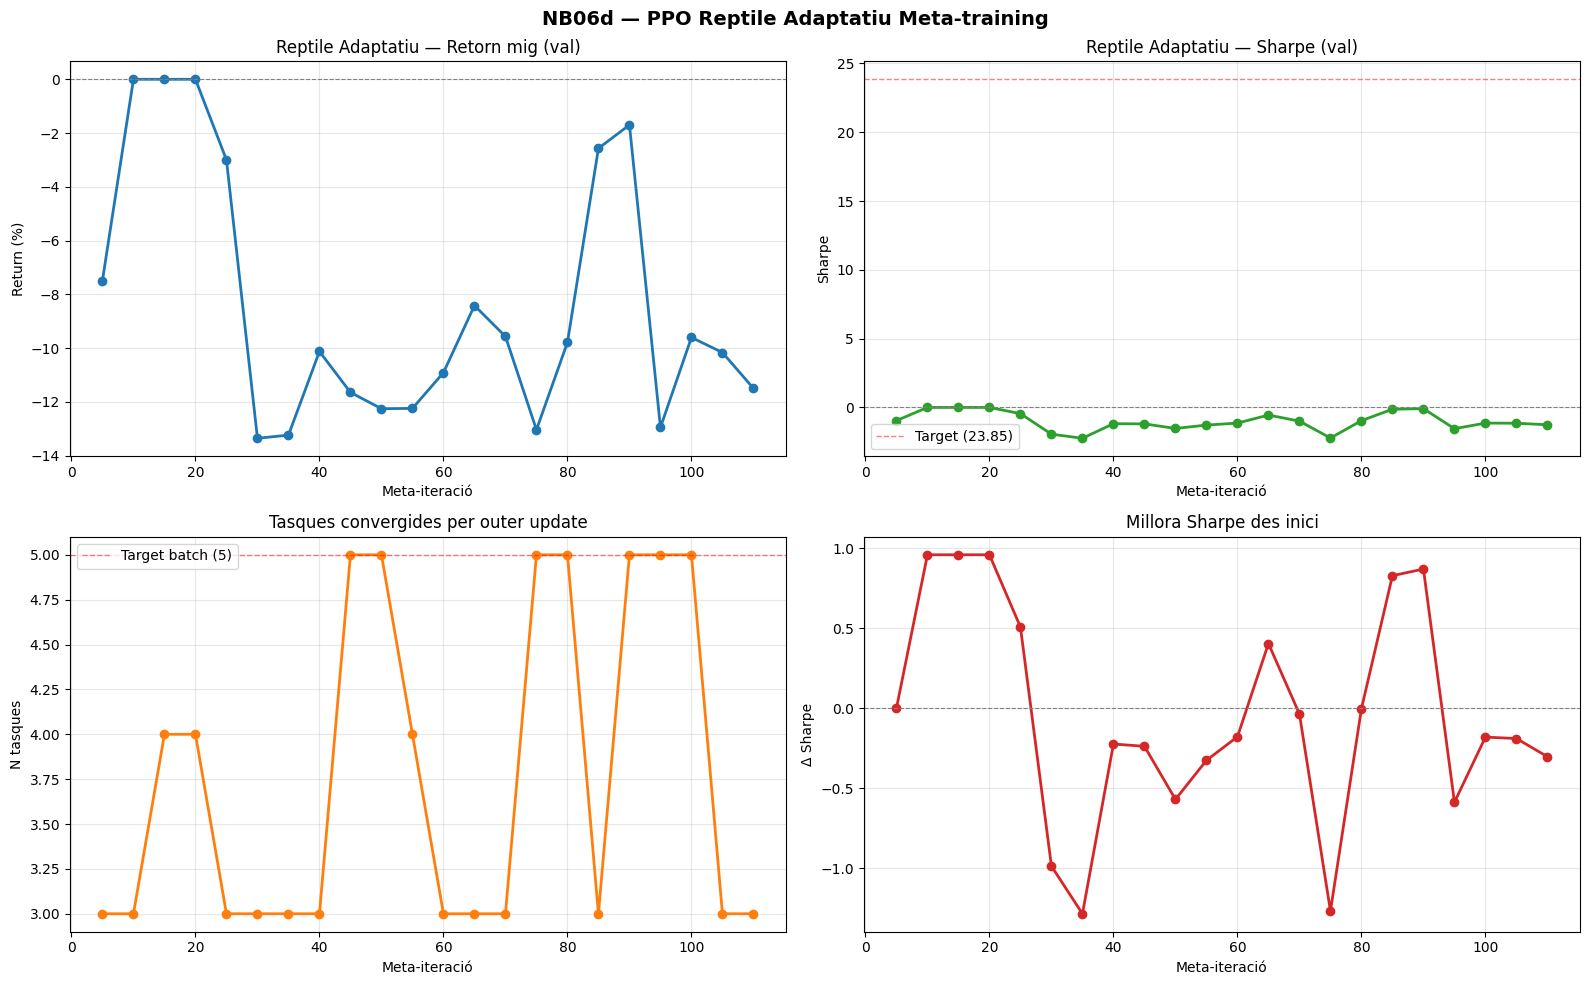

In [33]:
# =============================================================================
# CEL·LA 11 — META-TRAINING CURVES
# =============================================================================

if meta_history:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    iters = [h['meta_iter'] for h in meta_history]
    ret_v = [h['val_return'] for h in meta_history]
    sh_v  = [h['val_sharpe'] for h in meta_history]
    n_adapted = [h['n_adapted'] for h in meta_history]
    
    # Val Return
    axes[0, 0].plot(iters, ret_v, 'o-', color='#1f77b4', lw=2)
    axes[0, 0].axhline(0, color='gray', ls='--', lw=0.8)
    axes[0, 0].set_title('Reptile Adaptatiu — Retorn mig (val)')
    axes[0, 0].set_xlabel('Meta-iteració')
    axes[0, 0].set_ylabel('Return (%)')
    axes[0, 0].grid(alpha=0.3)
    
    # Val Sharpe
    axes[0, 1].plot(iters, sh_v, 'o-', color='#2ca02c', lw=2)
    axes[0, 1].axhline(0, color='gray', ls='--', lw=0.8)
    if meta_criteria.target_val_sharpe is not None:
        axes[0, 1].axhline(meta_criteria.target_val_sharpe, color='red', ls='--', lw=1.0, alpha=0.5, label=f'Target ({meta_criteria.target_val_sharpe})')
    axes[0, 1].set_title('Reptile Adaptatiu — Sharpe (val)')
    axes[0, 1].set_xlabel('Meta-iteració')
    axes[0, 1].set_ylabel('Sharpe')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # N tasques adaptades per batch
    axes[1, 0].plot(iters, n_adapted, 'o-', color='#ff7f0e', lw=2)
    axes[1, 0].axhline(outer_trigger.batch_size, color='red', ls='--', lw=1.0, alpha=0.5, label=f'Target batch ({outer_trigger.batch_size})')
    axes[1, 0].set_title('Tasques convergides per outer update')
    axes[1, 0].set_xlabel('Meta-iteració')
    axes[1, 0].set_ylabel('N tasques')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Millora acumulada
    if len(sh_v) > 0:
        improvement = [s - sh_v[0] for s in sh_v]
        axes[1, 1].plot(iters, improvement, 'o-', color='#d62728', lw=2)
        axes[1, 1].axhline(0, color='gray', ls='--', lw=0.8)
        axes[1, 1].set_title('Millora Sharpe des inici')
        axes[1, 1].set_xlabel('Meta-iteració')
        axes[1, 1].set_ylabel('Δ Sharpe')
        axes[1, 1].grid(alpha=0.3)
    
    plt.suptitle('NB06d — PPO Reptile Adaptatiu Meta-training', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'meta_training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Sense historial de meta-entrenament')

## Continua amb avaluació (rolling-window, etc.)

A partir d'aquí pots copiar les cel·les d'avaluació del notebook original (CEL·LA 12-18):
- `ppo_walk_forward`
- `ppo_rolling_meta_eval` (amb fast-adaptation)
- Equity curves
- Action distribution
- Comparative table

Les funcions d'avaluació són idèntiques, només canvia el `meta_policy` que és el resultat del sistema adaptatiu.